# MMDN self-supervised dynamic tracking, PyTorch version

This notebook implements the full MMDN workflow with PyTorch: supervised fixed-state pretraining, confidence-weighted three-model ensemble inference, pseudo-label self-supervised updates on drift states, and evaluation against true labels that are never used as dynamic training labels.

Place this notebook in the same directory as the dataset files. It first reads `.npz` files from the current directory. If no `.npz` exists, it falls back to the separate `.npy` files: `speckles.npy`, `pattern.npy`, `time_index.npy`, `counts_by_time.npy`, `kappa_by_time.npy`, and `kappa_per_sample.npy`.

In [1]:
from pathlib import Path
import json
import time
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Same-directory dataset loading. Do not hard-code local machine paths.
DATA_DIR = Path.cwd()
OUTPUT_DIR = DATA_DIR / "mmdn_dynamic_outputs_pytorch"
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / "models").mkdir(exist_ok=True)
(OUTPUT_DIR / "pseudo_labels").mkdir(exist_ok=True)

# Training controls. None means infer from metadata/counts when available.
SPECKLE_DIM = None
PRETRAIN_SAMPLES = None
SAMPLES_PER_DYNAMIC_STATE = None
LIMIT_DYNAMIC_STATES = None

BATCH_SIZE = 128
MAX_PRETRAIN_EPOCHS = 40
MAX_UPDATE_EPOCHS = 20
EARLY_STOP_PATIENCE = 6
REBUILD_INTERVAL = 5
LEARNING_RATE = 0.1
GRAYLEVEL = 2
NORMALIZE_SPECKLES = True
NUM_WORKERS = 0

# Split each dynamic state into smaller online intervals.
# None means one pseudo-label update per state; 1000 means a 5000-sample state has 5 online intervals.
DYNAMIC_CHUNK_SIZE = 1000
UPDATE_TRAIN_WINDOW = None  # None uses the latest dynamic chunk size.
USE_TRUE_LABELS_FOR_DYNAMIC_EARLY_STOPPING = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("data dir:", DATA_DIR)
print("output dir:", OUTPUT_DIR)
print("torch:", torch.__version__)
print("device:", DEVICE)

data dir: /root/MMDN
output dir: /root/MMDN/mmdn_dynamic_outputs_pytorch
torch: 2.3.0+cu121
device: cuda


In [3]:
def canonical_name(name):
    return name.lower().replace("-", "_").replace(" ", "_")


def load_arrays_from_npz(data_dir):
    arrays = {}
    for npz_path in sorted(data_dir.glob("*.npz")):
        archive = np.load(npz_path, allow_pickle=False)
        for key in archive.files:
            arrays[canonical_name(key)] = archive[key]
        if len(archive.files) == 1:
            arrays[canonical_name(npz_path.stem)] = archive[archive.files[0]]
    return arrays


def load_arrays_from_npy(data_dir):
    arrays = {}
    for npy_path in sorted(data_dir.glob("*.npy")):
        arrays[canonical_name(npy_path.stem)] = np.load(npy_path, mmap_mode="r")
    return arrays


def pick_array(arrays, candidates, required=True):
    for name in candidates:
        key = canonical_name(name)
        if key in arrays:
            return arrays[key]
    if required:
        raise KeyError(f"Could not find any of these arrays: {candidates}. Available keys: {sorted(arrays)}")
    return None


metadata = {}
metadata_path = DATA_DIR / "metadata.json"
if metadata_path.exists():
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

arrays = load_arrays_from_npz(DATA_DIR)
source_kind = "npz"
if not arrays:
    arrays = load_arrays_from_npy(DATA_DIR)
    source_kind = "npy"

speckles = pick_array(arrays, ["speckles", "speckle", "x", "inputs"])
patterns = pick_array(arrays, ["pattern", "patterns", "y", "labels", "targets"])
time_index = pick_array(arrays, ["time_index", "time", "state_index", "state"], required=False)
counts_by_time = pick_array(arrays, ["counts_by_time", "counts"], required=False)
kappa_by_time = pick_array(arrays, ["kappa_by_time"], required=False)
kappa_per_sample = pick_array(arrays, ["kappa_per_sample", "kappa"], required=False)

print("source kind:", source_kind)
print("available arrays:", sorted(arrays))
print("speckles:", speckles.shape, speckles.dtype)
print("patterns:", patterns.shape, patterns.dtype)
if time_index is not None:
    print("time_index:", time_index.shape, time_index.dtype, int(np.min(time_index)), int(np.max(time_index)))
if counts_by_time is not None:
    print("counts_by_time:", np.asarray(counts_by_time).astype(int).tolist())
if kappa_by_time is not None:
    print("kappa_by_time:", np.asarray(kappa_by_time).astype(float).tolist())

source kind: npy
available arrays: ['counts_by_time', 'kappa_by_time', 'kappa_per_sample', 'pattern', 'speckles', 'time_index']
speckles: (150000, 100, 100) uint8
patterns: (150000, 256) uint8
time_index: (150000,) int16 0 10
counts_by_time: [100000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
kappa_by_time: [0.0, 0.30000001192092896, 0.6000000238418579, 0.8999999761581421, 1.2000000476837158, 1.5, 1.7999999523162842, 2.0999999046325684, 2.4000000953674316, 2.700000047683716, 3.0]


In [4]:
def infer_segments(patterns, time_index, counts_by_time, metadata):
    n = int(patterns.shape[0])
    if counts_by_time is not None:
        counts = np.asarray(counts_by_time).astype(int).tolist()
    elif time_index is not None:
        unique, counts_arr = np.unique(np.asarray(time_index), return_counts=True)
        order = np.argsort(unique)
        counts = counts_arr[order].astype(int).tolist()
    else:
        hint = metadata.get("mmdn_training_hint", {})
        pre = int(PRETRAIN_SAMPLES or hint.get("sizeOfPretrain", n // 2))
        interval = int(SAMPLES_PER_DYNAMIC_STATE or hint.get("sizeOfUpdateInvertal", max(1, n - pre)))
        dyn = max(0, (n - pre) // interval)
        counts = [pre] + [interval] * dyn

    if sum(counts) > n:
        raise ValueError(f"Segment counts sum to {sum(counts)}, but only {n} samples exist.")

    segments = []
    start = 0
    for state_id, count in enumerate(counts):
        stop = start + int(count)
        segments.append({"state": state_id, "start": start, "stop": stop, "count": int(count)})
        start = stop
    return segments


segments = infer_segments(patterns, time_index, counts_by_time, metadata)
if LIMIT_DYNAMIC_STATES is not None:
    segments = [segments[0]] + segments[1:1 + int(LIMIT_DYNAMIC_STATES)]

if PRETRAIN_SAMPLES is not None:
    segments[0]["stop"] = segments[0]["start"] + int(PRETRAIN_SAMPLES)
    segments[0]["count"] = int(PRETRAIN_SAMPLES)

if SAMPLES_PER_DYNAMIC_STATE is not None:
    base = segments[0]["stop"]
    updated = [segments[0]]
    for i, old in enumerate(segments[1:], start=1):
        start = base + (i - 1) * int(SAMPLES_PER_DYNAMIC_STATE)
        stop = start + int(SAMPLES_PER_DYNAMIC_STATE)
        updated.append({"state": old["state"], "start": start, "stop": stop, "count": stop - start})
    segments = updated

speckle_dim = int(SPECKLE_DIM or metadata.get("mmdn_training_hint", {}).get("speckle_dim", speckles.shape[1]))
outsize = int(patterns.shape[1])

segment_df = pd.DataFrame(segments)
if kappa_by_time is not None and len(kappa_by_time) >= len(segment_df):
    segment_df["kappa"] = np.asarray(kappa_by_time)[:len(segment_df)]
display(segment_df)
print("speckle_dim:", speckle_dim, "outsize:", outsize)

,state,start,stop,count,kappa
0,0,0,100000,100000,0.0
1,1,100000,105000,5000,0.3
2,2,105000,110000,5000,0.6
3,3,110000,115000,5000,0.9
4,4,115000,120000,5000,1.2
5,5,120000,125000,5000,1.5
6,6,125000,130000,5000,1.8
7,7,130000,135000,5000,2.1
8,8,135000,140000,5000,2.4
9,9,140000,145000,5000,2.7


speckle_dim: 100 outsize: 256


In [5]:
class MMFDataset(Dataset):
    def __init__(self, x_array, sample_indices, labels=None, speckle_dim=None, normalize=True):
        self.x_array = x_array
        self.sample_indices = np.asarray(sample_indices, dtype=np.int64)
        self.labels = None if labels is None else np.asarray(labels, dtype=np.float32)
        self.speckle_dim = speckle_dim
        self.normalize = normalize

    def __len__(self):
        return len(self.sample_indices)

    def __getitem__(self, pos):
        sample_id = int(self.sample_indices[pos])
        x = np.asarray(self.x_array[sample_id], dtype=np.float32)
        if self.normalize:
            x = x / 255.0
        x = torch.from_numpy(x).unsqueeze(0)
        if self.speckle_dim is not None and (x.shape[-2] != self.speckle_dim or x.shape[-1] != self.speckle_dim):
            x = F.interpolate(x.unsqueeze(0), size=(self.speckle_dim, self.speckle_dim), mode="nearest").squeeze(0)
        if self.labels is None:
            return x
        y = torch.from_numpy(self.labels[pos])
        return x, y


class MMDNSubNetwork(nn.Module):
    def __init__(self, outsize, speckle_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(8, 8, kernel_size=3, stride=2),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, speckle_dim, speckle_dim)
            flat_dim = int(np.prod(self.features(dummy).shape[1:]))
        self.classifier = nn.Linear(flat_dim, outsize)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)


def indices_for_segment(seg):
    return np.arange(seg["start"], seg["stop"], dtype=np.int64)


def labels_for_indices(indices):
    return np.asarray(patterns[indices], dtype=np.uint8)


def make_loader(indices, labels=None, shuffle=False, batch_size=BATCH_SIZE):
    dataset = MMFDataset(
        speckles,
        indices,
        labels=labels,
        speckle_dim=speckle_dim,
        normalize=NORMALIZE_SPECKLES,
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())


def new_model():
    return MMDNSubNetwork(outsize=outsize, speckle_dim=speckle_dim).to(DEVICE)


def make_optimizer(model):
    return torch.optim.Adadelta(model.parameters(), lr=LEARNING_RATE)


clf1 = new_model()
clf2 = new_model()
clf3 = new_model()
optimizers = {
    "clf1": make_optimizer(clf1),
    "clf2": make_optimizer(clf2),
    "clf3": make_optimizer(clf3),
}
print(clf3)
print("parameters:", sum(p.numel() for p in clf3.parameters()))

MMDNSubNetwork(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout2d(p=0.4, inplace=False)
    (4): Conv2d(8, 8, kernel_size=(3, 3), stride=(2, 2))
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout2d(p=0.4, inplace=False)
  )
  (classifier): Linear(in_features=18432, out_features=256, bias=True)
)
parameters: 4719544


In [6]:
def binarize(pred, graylevel=2):
    pred = np.clip(pred, 0.0, 1.0)
    if graylevel == 2:
        return (pred >= 0.5).astype(np.uint8)
    return ((0.5 + pred * (graylevel - 1)).astype(np.uint8) / (graylevel - 1)).astype(np.float16)


def confidence_level(pred):
    return float(np.mean(np.abs(pred - 0.5) * 1.8 + 0.1))


def confidence_weights(c1, c2, c3):
    denom = max(1e-6, 3.0 - c1 - c2 - c3)
    logits = np.array([
        10.0 * (2.0 - c2 - c3) / denom,
        10.0 * (2.0 - c1 - c3) / denom,
        10.0 * (2.0 - c1 - c2) / denom,
    ], dtype=np.float64)
    logits = logits - np.max(logits)
    weights = np.exp(logits)
    return weights / np.sum(weights)


def predict_prob(model, indices, batch_size=BATCH_SIZE):
    model.eval()
    preds = []
    loader = make_loader(indices, labels=None, shuffle=False, batch_size=batch_size)
    with torch.no_grad():
        for x in loader:
            x = x.to(DEVICE, non_blocking=True)
            preds.append(torch.sigmoid(model(x)).detach().cpu().numpy())
    return np.concatenate(preds, axis=0)


def evaluate_prediction(y_true, y_pred_binary):
    y_true = np.asarray(y_true)
    y_pred_binary = np.asarray(y_pred_binary)
    sample_accuracy = np.mean(y_true == y_pred_binary, axis=1) * 100.0
    return {
        "pixel_accuracy": float(np.mean(y_true == y_pred_binary) * 100.0),
        "sample_accuracy_mean": float(np.mean(sample_accuracy)),
        "sample_accuracy_std": float(np.std(sample_accuracy)),
        "exact_match_percent": float(np.mean(np.all(y_true == y_pred_binary, axis=1)) * 100.0),
        "mae": float(np.mean(np.abs(y_true.astype(np.float32) - y_pred_binary.astype(np.float32)))),
    }


def ensemble_predict(indices):
    p1 = predict_prob(clf1, indices)
    p2 = predict_prob(clf2, indices)
    p3 = predict_prob(clf3, indices)
    c1, c2, c3 = confidence_level(p1), confidence_level(p2), confidence_level(p3)
    w = confidence_weights(c1, c2, c3)
    prob = w[0] * p1 + w[1] * p2 + w[2] * p3
    pred = binarize(prob, GRAYLEVEL)
    return pred, prob, (p1, p2, p3), (c1, c2, c3), w


def run_validation_loss(model, val_loader, criterion):
    model.eval()
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += float(loss.item()) * x.size(0)
            total_count += x.size(0)
    return total_loss / max(1, total_count)


def fit_on_memory(model, optimizer, train_indices, train_labels, val_indices=None, val_labels=None, epochs=1, name="train"):
    train_loader = make_loader(train_indices, labels=train_labels, shuffle=True)
    val_loader = None if val_indices is None or val_labels is None else make_loader(val_indices, labels=val_labels, shuffle=False)
    criterion = nn.BCEWithLogitsLoss()
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_optimizer_state = copy.deepcopy(optimizer.state_dict())
    best_metric = float("inf")
    wait = 0
    history = []

    for epoch in range(1, int(epochs) + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.item()) * x.size(0)
            total_count += x.size(0)

        train_loss = total_loss / max(1, total_count)
        if val_loader is not None:
            val_loss = run_validation_loss(model, val_loader, criterion)
            monitor = val_loss
        else:
            val_loss = np.nan
            monitor = train_loss
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        print(f"{name} epoch {epoch:03d}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}")

        if monitor < best_metric - 5e-6:
            best_metric = monitor
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= EARLY_STOP_PATIENCE:
                print(f"{name}: early stopping at epoch {epoch}")
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    optimizer.load_state_dict(best_optimizer_state)
    pd.DataFrame(history).to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
    return history

In [7]:
if len(segments) < 2:
    raise ValueError("Need one pretraining segment plus at least one dynamic segment.")

pretrain_indices = indices_for_segment(segments[0])
pretrain_labels = labels_for_indices(pretrain_indices)
first_dynamic_indices = indices_for_segment(segments[1])
first_dynamic_labels = labels_for_indices(first_dynamic_indices)

memory_indices = pretrain_indices.copy()
memory_labels = pretrain_labels.copy()
memory_limit = len(pretrain_indices)
update_batch_size = int(segments[1]["count"])

print("pretraining samples:", len(pretrain_indices))
print("dynamic states:", len(segments) - 1)
print("samples per first dynamic state:", update_batch_size)

t0 = time.time()
print("Pretraining L3/clf3 on full initial memory")
fit_on_memory(clf3, optimizers["clf3"], memory_indices, memory_labels, first_dynamic_indices, first_dynamic_labels, MAX_PRETRAIN_EPOCHS, "pretrain_clf3")

print("Pretraining S2/clf2 on last 3/4 of initial memory")
n2 = max(1, int(len(memory_indices) * 3 / 4))
fit_on_memory(clf2, optimizers["clf2"], memory_indices[-n2:], memory_labels[-n2:], first_dynamic_indices, first_dynamic_labels, MAX_PRETRAIN_EPOCHS, "pretrain_clf2")

print("Pretraining S1/clf1 on last 2/3 of initial memory")
n1 = max(1, int(len(memory_indices) * 2 / 3))
fit_on_memory(clf1, optimizers["clf1"], memory_indices[-n1:], memory_labels[-n1:], first_dynamic_indices, first_dynamic_labels, MAX_PRETRAIN_EPOCHS, "pretrain_clf1")

static_clf3 = new_model()
static_clf3.load_state_dict({k: v.detach().clone() for k, v in clf3.state_dict().items()})

torch.save(clf1.state_dict(), OUTPUT_DIR / "models" / "pretrain_clf1.pt")
torch.save(clf2.state_dict(), OUTPUT_DIR / "models" / "pretrain_clf2.pt")
torch.save(clf3.state_dict(), OUTPUT_DIR / "models" / "pretrain_clf3.pt")
print(f"pretraining finished in {(time.time() - t0) / 60:.2f} min")

# Fixed-state evaluation after supervised pretraining. If all t=0 samples were
# used for training, this is training-state accuracy, not drift-tracking accuracy.
fixed_eval_count = min(10000, len(pretrain_indices))
fixed_eval_indices = pretrain_indices[-fixed_eval_count:]
fixed_true_labels = labels_for_indices(fixed_eval_indices)
fixed_pred_ensemble, _, fixed_indiv_probs, fixed_confs, fixed_weights = ensemble_predict(fixed_eval_indices)
fixed_pred1 = binarize(fixed_indiv_probs[0], GRAYLEVEL)
fixed_pred2 = binarize(fixed_indiv_probs[1], GRAYLEVEL)
fixed_pred3 = binarize(fixed_indiv_probs[2], GRAYLEVEL)
fixed_static = binarize(predict_prob(static_clf3, fixed_eval_indices), GRAYLEVEL)

fixed_row = {
    "state": int(segments[0]["state"]),
    "samples_evaluated": int(fixed_eval_count),
    "ensemble_pixel_acc": evaluate_prediction(fixed_true_labels, fixed_pred_ensemble)["pixel_accuracy"],
    "s1_pixel_acc": evaluate_prediction(fixed_true_labels, fixed_pred1)["pixel_accuracy"],
    "s2_pixel_acc": evaluate_prediction(fixed_true_labels, fixed_pred2)["pixel_accuracy"],
    "l3_pixel_acc": evaluate_prediction(fixed_true_labels, fixed_pred3)["pixel_accuracy"],
    "static_l3_pixel_acc": evaluate_prediction(fixed_true_labels, fixed_static)["pixel_accuracy"],
    "ensemble_exact_match": evaluate_prediction(fixed_true_labels, fixed_pred_ensemble)["exact_match_percent"],
    "ensemble_mae": evaluate_prediction(fixed_true_labels, fixed_pred_ensemble)["mae"],
    "conf_s1": fixed_confs[0],
    "conf_s2": fixed_confs[1],
    "conf_l3": fixed_confs[2],
    "weight_s1": float(fixed_weights[0]),
    "weight_s2": float(fixed_weights[1]),
    "weight_l3": float(fixed_weights[2]),
}
fixed_metrics_df = pd.DataFrame([fixed_row])
fixed_metrics_df.to_csv(OUTPUT_DIR / "fixed_state_pretrain_metrics.csv", index=False)
display(fixed_metrics_df)
print(f"fixed-state ensemble accuracy: {fixed_row['ensemble_pixel_acc']:.4f}%")

pretraining samples: 100000
dynamic states: 10
samples per first dynamic state: 5000
Pretraining L3/clf3 on full initial memory
pretrain_clf3 epoch 001: train_loss=0.540603, val_loss=0.362081
pretrain_clf3 epoch 002: train_loss=0.276775, val_loss=0.227716
pretrain_clf3 epoch 003: train_loss=0.175329, val_loss=0.179104
pretrain_clf3 epoch 004: train_loss=0.131809, val_loss=0.172046
pretrain_clf3 epoch 005: train_loss=0.109061, val_loss=0.160315
pretrain_clf3 epoch 006: train_loss=0.095646, val_loss=0.163610
pretrain_clf3 epoch 007: train_loss=0.085726, val_loss=0.160649
pretrain_clf3 epoch 008: train_loss=0.079397, val_loss=0.168631
pretrain_clf3 epoch 009: train_loss=0.074309, val_loss=0.159071
pretrain_clf3 epoch 010: train_loss=0.070024, val_loss=0.163779
pretrain_clf3 epoch 011: train_loss=0.066697, val_loss=0.165217
pretrain_clf3 epoch 012: train_loss=0.064288, val_loss=0.159102
pretrain_clf3 epoch 013: train_loss=0.061738, val_loss=0.175327
pretrain_clf3 epoch 014: train_loss=0.05

,state,samples_evaluated,ensemble_pixel_acc,s1_pixel_acc,s2_pixel_acc,l3_pixel_acc,static_l3_pixel_acc,ensemble_exact_match,ensemble_mae,conf_s1,conf_s2,conf_l3,weight_s1,weight_s2,weight_l3
0,0,10000,99.456719,99.263984,99.345313,99.283516,99.283516,29.56,0.005433,0.956833,0.964542,0.970404,0.152822,0.311589,0.535589


fixed-state ensemble accuracy: 99.4567%


In [8]:
rows = []
global_update = 0

def split_dynamic_indices(indices):
    if DYNAMIC_CHUNK_SIZE is None or int(DYNAMIC_CHUNK_SIZE) <= 0 or len(indices) <= int(DYNAMIC_CHUNK_SIZE):
        return [indices]
    return [indices[i:i + int(DYNAMIC_CHUNK_SIZE)] for i in range(0, len(indices), int(DYNAMIC_CHUNK_SIZE))]

for state_step, seg in enumerate(segments[1:], start=1):
    state = int(seg["state"])
    state_indices = indices_for_segment(seg)
    state_chunks = split_dynamic_indices(state_indices)
    print("=" * 80)
    print(f"dynamic state {state_step}/{len(segments) - 1}, state={state}, samples={len(state_indices)}, chunks={len(state_chunks)}")

    for chunk_id, current_indices in enumerate(state_chunks, start=1):
        global_update += 1
        true_labels = labels_for_indices(current_indices)
        print("-" * 80)
        print(f"state={state}, chunk={chunk_id}/{len(state_chunks)}, online_update={global_update}, samples={len(current_indices)}")

        if global_update > 1:
            train_window = int(UPDATE_TRAIN_WINDOW or DYNAMIC_CHUNK_SIZE or update_batch_size)
            train_n = min(train_window, len(memory_indices))
            train_indices = memory_indices[-train_n:]
            train_labels = memory_labels[-train_n:]
            dyn_val_indices = current_indices if USE_TRUE_LABELS_FOR_DYNAMIC_EARLY_STOPPING else None
            dyn_val_labels = true_labels if USE_TRUE_LABELS_FOR_DYNAMIC_EARLY_STOPPING else None

            if chunk_id == 1 and state_step % (2 * REBUILD_INTERVAL) == REBUILD_INTERVAL + 1:
                print("Rebuilding S1/clf1 from recent pseudo-labeled memory")
                clf1 = new_model()
                optimizers["clf1"] = make_optimizer(clf1)
                rebuild_n = min(len(memory_indices), max(train_n, int(memory_limit * 2 / 3)))
                fit_on_memory(
                    clf1, optimizers["clf1"],
                    memory_indices[-rebuild_n:], memory_labels[-rebuild_n:],
                    dyn_val_indices, dyn_val_labels,
                    MAX_UPDATE_EPOCHS, f"rebuild_state{state:02d}_chunk{chunk_id:02d}_clf1",
                )

            if chunk_id == 1 and state_step % (2 * REBUILD_INTERVAL) == 1 and state_step > 1:
                print("Rebuilding S2/clf2 from recent pseudo-labeled memory")
                clf2 = new_model()
                optimizers["clf2"] = make_optimizer(clf2)
                rebuild_n = min(len(memory_indices), max(train_n, int(memory_limit * 3 / 4)))
                fit_on_memory(
                    clf2, optimizers["clf2"],
                    memory_indices[-rebuild_n:], memory_labels[-rebuild_n:],
                    dyn_val_indices, dyn_val_labels,
                    MAX_UPDATE_EPOCHS, f"rebuild_state{state:02d}_chunk{chunk_id:02d}_clf2",
                )

            print("Fine-tuning L3/clf3 on latest pseudo-labeled interval")
            fit_on_memory(
                clf3, optimizers["clf3"], train_indices, train_labels,
                dyn_val_indices, dyn_val_labels,
                MAX_UPDATE_EPOCHS, f"update_state{state:02d}_chunk{chunk_id:02d}_clf3",
            )
            print("Fine-tuning S2/clf2 on latest pseudo-labeled interval")
            fit_on_memory(
                clf2, optimizers["clf2"], train_indices, train_labels,
                dyn_val_indices, dyn_val_labels,
                MAX_UPDATE_EPOCHS, f"update_state{state:02d}_chunk{chunk_id:02d}_clf2",
            )
            print("Fine-tuning S1/clf1 on latest pseudo-labeled interval")
            fit_on_memory(
                clf1, optimizers["clf1"], train_indices, train_labels,
                dyn_val_indices, dyn_val_labels,
                MAX_UPDATE_EPOCHS, f"update_state{state:02d}_chunk{chunk_id:02d}_clf1",
            )

        pred_ensemble, prob_ensemble, indiv_probs, confs, weights = ensemble_predict(current_indices)
        pred1 = binarize(indiv_probs[0], GRAYLEVEL)
        pred2 = binarize(indiv_probs[1], GRAYLEVEL)
        pred3 = binarize(indiv_probs[2], GRAYLEVEL)
        pred_static = binarize(predict_prob(static_clf3, current_indices), GRAYLEVEL)

        ens_metrics = evaluate_prediction(true_labels, pred_ensemble)
        m1_metrics = evaluate_prediction(true_labels, pred1)
        m2_metrics = evaluate_prediction(true_labels, pred2)
        m3_metrics = evaluate_prediction(true_labels, pred3)
        static_metrics = evaluate_prediction(true_labels, pred_static)

        kappa_value = None
        if kappa_by_time is not None and state < len(kappa_by_time):
            kappa_value = float(kappa_by_time[state])
        elif kappa_per_sample is not None:
            kappa_value = float(np.mean(kappa_per_sample[current_indices]))

        row = {
            "online_update": global_update,
            "state_step": state_step,
            "state": state,
            "chunk": chunk_id,
            "chunks_in_state": len(state_chunks),
            "start": int(current_indices[0]),
            "stop": int(current_indices[-1]) + 1,
            "samples": int(len(current_indices)),
            "kappa": kappa_value,
            "ensemble_pixel_acc": ens_metrics["pixel_accuracy"],
            "s1_pixel_acc": m1_metrics["pixel_accuracy"],
            "s2_pixel_acc": m2_metrics["pixel_accuracy"],
            "l3_pixel_acc": m3_metrics["pixel_accuracy"],
            "static_l3_pixel_acc": static_metrics["pixel_accuracy"],
            "ensemble_exact_match": ens_metrics["exact_match_percent"],
            "ensemble_mae": ens_metrics["mae"],
            "conf_s1": confs[0],
            "conf_s2": confs[1],
            "conf_l3": confs[2],
            "weight_s1": float(weights[0]),
            "weight_s2": float(weights[1]),
            "weight_l3": float(weights[2]),
        }
        rows.append(row)

        np.save(OUTPUT_DIR / "pseudo_labels" / f"pseudo_state_{state:02d}_chunk_{chunk_id:02d}.npy", pred_ensemble.astype(np.uint8))

        memory_indices = np.concatenate([memory_indices, current_indices])[-memory_limit:]
        memory_labels = np.concatenate([memory_labels, pred_ensemble.astype(np.uint8)])[-memory_limit:]

        metrics_df = pd.DataFrame(rows)
        metrics_df.to_csv(OUTPUT_DIR / "dynamic_tracking_metrics.csv", index=False)
        display(metrics_df.tail(1))
        print(f"ensemble={row['ensemble_pixel_acc']:.4f}%, static={row['static_l3_pixel_acc']:.4f}%")

torch.save(clf1.state_dict(), OUTPUT_DIR / "models" / "final_clf1.pt")
torch.save(clf2.state_dict(), OUTPUT_DIR / "models" / "final_clf2.pt")
torch.save(clf3.state_dict(), OUTPUT_DIR / "models" / "final_clf3.pt")
metrics_df = pd.DataFrame(rows)
display(metrics_df)


dynamic step 1/10, state=1, samples=5000


,step,state,start,stop,samples,kappa,ensemble_pixel_acc,s1_pixel_acc,s2_pixel_acc,l3_pixel_acc,static_l3_pixel_acc,ensemble_exact_match,ensemble_mae,conf_s1,conf_s2,conf_l3,weight_s1,weight_s2,weight_l3
0,1,1,100000,105000,5000,0.3,94.740391,94.271719,94.472813,94.068359,94.068359,0.0,0.052596,0.899475,0.910801,0.919049,0.218314,0.33175,0.449937


ensemble=94.7404%, static=94.0684%
dynamic step 2/10, state=2, samples=5000
Fine-tuning L3/clf3 on previous pseudo-labeled state
update_step02_clf3 epoch 001: train_loss=0.152891, val_loss=0.207837
update_step02_clf3 epoch 002: train_loss=0.147041, val_loss=0.147307
update_step02_clf3 epoch 003: train_loss=0.142550, val_loss=0.172160
update_step02_clf3 epoch 004: train_loss=0.138287, val_loss=0.165663
update_step02_clf3 epoch 005: train_loss=0.135088, val_loss=0.203011
update_step02_clf3 epoch 006: train_loss=0.131891, val_loss=0.167202
update_step02_clf3 epoch 007: train_loss=0.129683, val_loss=0.159741
update_step02_clf3 epoch 008: train_loss=0.125434, val_loss=0.163535
update_step02_clf3: early stopping at epoch 8
Fine-tuning S2/clf2 on previous pseudo-labeled state
update_step02_clf2 epoch 001: train_loss=0.159965, val_loss=0.162771
update_step02_clf2 epoch 002: train_loss=0.151850, val_loss=0.168502
update_step02_clf2 epoch 003: train_loss=0.147387, val_loss=0.167742
update_step02

,step,state,start,stop,samples,kappa,ensemble_pixel_acc,s1_pixel_acc,s2_pixel_acc,l3_pixel_acc,static_l3_pixel_acc,ensemble_exact_match,ensemble_mae,conf_s1,conf_s2,conf_l3,weight_s1,weight_s2,weight_l3
1,2,2,105000,110000,5000,0.6,95.7275,94.936406,94.784844,94.478125,94.156172,0.0,0.042725,0.91034,0.92148,0.92026,0.246345,0.386096,0.367559


ensemble=95.7275%, static=94.1562%
dynamic step 3/10, state=3, samples=5000
Fine-tuning L3/clf3 on previous pseudo-labeled state
update_step03_clf3 epoch 001: train_loss=0.143365, val_loss=0.180523
update_step03_clf3 epoch 002: train_loss=0.136236, val_loss=0.167207
update_step03_clf3 epoch 003: train_loss=0.131416, val_loss=0.151975
update_step03_clf3 epoch 004: train_loss=0.126650, val_loss=0.160450
update_step03_clf3 epoch 005: train_loss=0.120851, val_loss=0.163237
update_step03_clf3 epoch 006: train_loss=0.121665, val_loss=0.145105
update_step03_clf3 epoch 007: train_loss=0.116826, val_loss=0.166581
update_step03_clf3 epoch 008: train_loss=0.115249, val_loss=0.145415
update_step03_clf3 epoch 009: train_loss=0.113283, val_loss=0.150518
update_step03_clf3 epoch 010: train_loss=0.109169, val_loss=0.159420
update_step03_clf3 epoch 011: train_loss=0.107905, val_loss=0.141777
update_step03_clf3 epoch 012: train_loss=0.107659, val_loss=0.159125
update_step03_clf3 epoch 013: train_loss=0.

...

,step,state,start,stop,samples,kappa,ensemble_pixel_acc,s1_pixel_acc,s2_pixel_acc,l3_pixel_acc,static_l3_pixel_acc,ensemble_exact_match,ensemble_mae,conf_s1,conf_s2,conf_l3,weight_s1,weight_s2,weight_l3
8,9,9,140000,145000,5000,2.7,91.194141,90.679531,90.125703,90.202187,90.046016,0.0,0.088059,0.907754,0.90466,0.914464,0.315319,0.281547,0.403133


ensemble=91.1941%, static=90.0460%
dynamic step 10/10, state=10, samples=5000
Fine-tuning L3/clf3 on previous pseudo-labeled state
update_step10_clf3 epoch 001: train_loss=0.160001, val_loss=0.547402
update_step10_clf3 epoch 002: train_loss=0.151869, val_loss=0.518118
update_step10_clf3 epoch 003: train_loss=0.147975, val_loss=0.549757
update_step10_clf3 epoch 004: train_loss=0.142698, val_loss=0.583193
update_step10_clf3 epoch 005: train_loss=0.139000, val_loss=0.530617
update_step10_clf3 epoch 006: train_loss=0.134461, val_loss=0.518639
update_step10_clf3 epoch 007: train_loss=0.132353, val_loss=0.483710
update_step10_clf3 epoch 008: train_loss=0.131388, val_loss=0.511747
update_step10_clf3 epoch 009: train_loss=0.128939, val_loss=0.514626
update_step10_clf3 epoch 010: train_loss=0.124080, val_loss=0.531069
update_step10_clf3 epoch 011: train_loss=0.124529, val_loss=0.509682
update_step10_clf3 epoch 012: train_loss=0.121766, val_loss=0.516914
update_step10_clf3 epoch 013: train_loss=

,step,state,start,stop,samples,kappa,ensemble_pixel_acc,s1_pixel_acc,s2_pixel_acc,l3_pixel_acc,static_l3_pixel_acc,ensemble_exact_match,ensemble_mae,conf_s1,conf_s2,conf_l3,weight_s1,weight_s2,weight_l3
9,10,10,145000,150000,5000,3.0,87.898984,87.221719,86.952812,86.886328,86.009766,0.0,0.12101,0.901711,0.89354,0.904601,0.349313,0.266065,0.384622


ensemble=87.8990%, static=86.0098%


,step,state,start,stop,samples,kappa,ensemble_pixel_acc,s1_pixel_acc,s2_pixel_acc,l3_pixel_acc,static_l3_pixel_acc,ensemble_exact_match,ensemble_mae,conf_s1,conf_s2,conf_l3,weight_s1,weight_s2,weight_l3
0,1,1,100000,105000,5000,0.3,94.740391,94.271719,94.472813,94.068359,94.068359,0.0,0.052596,0.899475,0.910801,0.919049,0.218314,0.331750,0.449937
1,2,2,105000,110000,5000,0.6,95.727500,94.936406,94.784844,94.478125,94.156172,0.0,0.042725,0.910340,0.921480,0.920260,0.246345,0.386096,0.367559
2,3,3,110000,115000,5000,0.9,96.047031,95.153672,95.293984,94.971484,93.565781,0.0,0.039530,0.915840,0.924822,0.929288,0.234093,0.345900,0.420007
3,4,4,115000,120000,5000,1.2,94.348203,93.475000,93.178281,93.443672,91.762188,0.0,0.056518,0.895976,0.903649,0.911279,0.249888,0.325851,0.424262
4,5,5,120000,125000,5000,1.5,94.411641,93.290703,93.409219,92.991094,91.299688,0.0,0.055884,0.904815,0.909549,0.916080,0.269484,0.321221,0.409295
5,6,6,125000,130000,5000,1.8,92.826719,92.114453,91.630703,91.502266,92.021563,0.0,0.071733,0.903296,0.902348,0.908500,0.315752,0.305449,0.378800
6,7,7,130000,135000,5000,2.1,93.736250,92.920937,92.273984,92.850781,93.703906,0.0,0.062638,0.918927,0.912814,0.924177,0.331295,0.257899,0.410807
7,8,8,135000,140000,5000,2.4,93.338437,92.801094,91.926094,92.300625,93.067813,0.0,0.066616,0.924689,0.917600,0.927841,0.347027,0.254941,0.398032
8,9,9,140000,145000,5000,2.7,91.194141,90.679531,90.125703,90.202187,90.046016,0.0,0.088059,0.907754,0.904660,0.914464,0.315319,0.281547,0.403133
9,10,10,145000,150000,5000,3.0,87.898984,87.221719,86.952812,86.886328,86.009766,0.0,0.121010,0.901711,0.893540,0.904601,0.349313,0.266065,0.384622


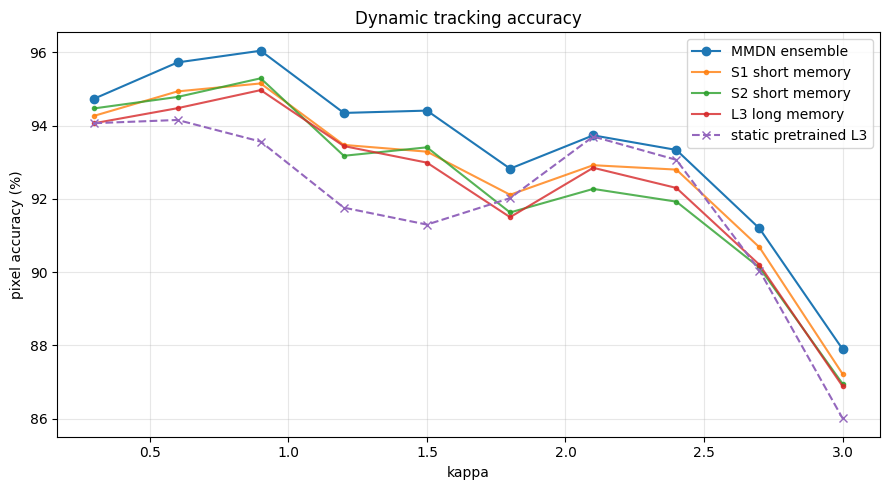

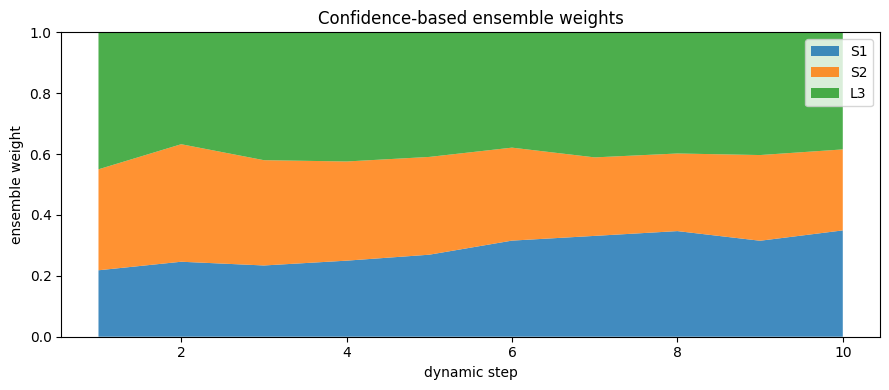

saved: /root/MMDN/mmdn_dynamic_outputs_pytorch/fixed_state_pretrain_metrics.csv
saved: /root/MMDN/mmdn_dynamic_outputs_pytorch/dynamic_tracking_metrics.csv
saved: /root/MMDN/mmdn_dynamic_outputs_pytorch/dynamic_tracking_metrics.xlsx
saved: /root/MMDN/mmdn_dynamic_outputs_pytorch/accuracy_over_drift.png
saved: /root/MMDN/mmdn_dynamic_outputs_pytorch/ensemble_weights.png


In [9]:
metrics_df = pd.read_csv(OUTPUT_DIR / "dynamic_tracking_metrics.csv")

x_axis = metrics_df["kappa"] if "kappa" in metrics_df and metrics_df["kappa"].notna().all() else metrics_df["online_update"]
x_label = "kappa" if "kappa" in metrics_df and metrics_df["kappa"].notna().all() else "dynamic step"

plt.figure(figsize=(9, 5))
plt.plot(x_axis, metrics_df["ensemble_pixel_acc"], marker="o", label="MMDN ensemble")
plt.plot(x_axis, metrics_df["s1_pixel_acc"], marker=".", label="S1 short memory", alpha=0.8)
plt.plot(x_axis, metrics_df["s2_pixel_acc"], marker=".", label="S2 short memory", alpha=0.8)
plt.plot(x_axis, metrics_df["l3_pixel_acc"], marker=".", label="L3 long memory", alpha=0.8)
plt.plot(x_axis, metrics_df["static_l3_pixel_acc"], marker="x", label="static pretrained L3", linestyle="--")
plt.xlabel(x_label)
plt.ylabel("pixel accuracy (%)")
plt.title("Dynamic tracking accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_over_drift.png", dpi=180)
plt.show()

plt.figure(figsize=(9, 4))
plt.stackplot(
    metrics_df["online_update"],
    metrics_df["weight_s1"],
    metrics_df["weight_s2"],
    metrics_df["weight_l3"],
    labels=["S1", "S2", "L3"],
    alpha=0.85,
)
plt.xlabel("online update")
plt.ylabel("ensemble weight")
plt.title("Confidence-based ensemble weights")
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ensemble_weights.png", dpi=180)
plt.show()

metrics_df.to_excel(OUTPUT_DIR / "dynamic_tracking_metrics.xlsx", index=False)
print("saved:", OUTPUT_DIR / "fixed_state_pretrain_metrics.csv")
print("saved:", OUTPUT_DIR / "dynamic_tracking_metrics.csv")
print("saved:", OUTPUT_DIR / "dynamic_tracking_metrics.xlsx")
print("saved:", OUTPUT_DIR / "accuracy_over_drift.png")
print("saved:", OUTPUT_DIR / "ensemble_weights.png")